In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [2]:
df_students = pd.read_excel('../data/StudentsPrepared.xlsx')
df_students.head(10)

,EstadoCivil,Curso,QualificacaoAnterior,QualificacaoAnteriorGrau,Nacionalidade,NotaAdmissao,NecessidadesEspeciais,Devedor,MensalidadesEmDia,Genero,...,UnidadesCurriculares2SemestreCreditado,UnidadesCurriculares2SemestreInscrito,UnidadesCurriculares2SemestreAvaliacoes,UnidadesCurriculares2SemestreAprovado,UnidadesCurriculares2SemestreGrau,UnidadesCurriculares2SemestreSemAvaliacoes,TaxaDesemprego,TaxaInflacao,PIB,Target
0,Solteiro,Design de Animação e Multimédia,Ensino Secundário,122.0,Português,127.3,0,0,1,Masculino,...,0,0,0,0,0.000000e+00,0,10.8,1.4,1.74,Desistente
1,Solteiro,Turismo,Ensino Secundário,160.0,Português,142.5,0,0,0,Masculino,...,0,6,6,6,1.366667e+16,0,13.9,-0.3,0.79,Graduado
2,Solteiro,Design de Comunicação,Ensino Secundário,122.0,Português,124.8,0,0,0,Masculino,...,0,6,0,0,0.000000e+00,0,10.8,1.4,1.74,Desistente
3,Solteiro,Jornalismo e Comunicação,Ensino Secundário,122.0,Português,119.6,0,0,1,Feminino,...,0,6,10,5,1.240000e+01,0,9.4,-0.8,-3.12,Graduado
4,Casado,Serviço Social (prestação nocturna),Ensino Secundário,100.0,Português,141.5,0,0,1,Feminino,...,0,6,6,6,1.300000e+01,0,13.9,-0.3,0.79,Graduado
5,Casado,Gestão (presencial noturno),Ensino Básico (3º Ciclo),133.1,Português,114.8,0,1,1,Masculino,...,0,5,17,5,1.150000e+01,5,16.2,0.3,-0.92,Graduado
6,Solteiro,Enfermagem,Ensino Secundário,142.0,Português,128.4,0,0,1,Feminino,...,0,8,8,8,1.434500e+04,0,15.5,2.8,-4.06,Graduado
7,Solteiro,Turismo,Ensino Secundário,119.0,Português,113.1,0,0,0,Masculino,...,0,5,5,0,0.000000e+00,0,15.5,2.8,-4.06,Desistente
8,Solteiro,Serviço Social,Ensino Secundário,137.0,Romeno,129.3,0,0,1,Feminino,...,0,6,7,6,1.414286e+16,0,16.2,0.3,-0.92,Graduado
9,Solteiro,Serviço Social,Ensino Secundário,138.0,Português,123.0,0,1,0,Feminino,...,0,6,14,2,1.350000e+01,0,8.9,1.4,3.51,Desistente


Analisando o documento XLSX, encontramos valores fora do comum nas colunas UnidadesCurriculares1SemestreGrau e UnidadesCurriculares2SemestreGrau.

Ao inspecionar a célula bruta, confirmamos que não é um erro de formatação/exibição do Excel — o valor gigante
está mesmo gravado na planilha, provavelmente por um bug na etapa de export dos dados.

Além disso, os valores anômalos não seguem uma única escala: a maioria está multiplicada por ~1e15, mas um subgrupo menor está multiplicado por ~1e3.

Por isso, em vez de dividir por um fator fixo, aplicamos um loop que divide por 10 repetidamente até o valor cair dentro da faixa esperada (0 a 20).

In [3]:
print(f'min: 1Semestre', min(df_students['UnidadesCurriculares1SemestreGrau']))
print(f'min 2Semestre: ', min(df_students['UnidadesCurriculares2SemestreGrau']))

print(f'max: 1Semestre', max(df_students['UnidadesCurriculares1SemestreGrau']))
print(f'max 2Semestre: ', max(df_students['UnidadesCurriculares2SemestreGrau']))

print('--------------------------------')

c_1_semestre_grau = df_students['UnidadesCurriculares1SemestreGrau']
while (c_1_semestre_grau > 20).any():
	c_1_semestre_grau = c_1_semestre_grau.where(
		c_1_semestre_grau <= 20, c_1_semestre_grau/10)
df_students['UnidadesCurriculares1SemestreGrau'] = c_1_semestre_grau


c_2_semestre_grau = df_students['UnidadesCurriculares2SemestreGrau']
while (c_2_semestre_grau > 20).any():
	c_2_semestre_grau = c_2_semestre_grau.where(
		c_2_semestre_grau <= 20, c_2_semestre_grau/10)
df_students['UnidadesCurriculares2SemestreGrau'] = c_2_semestre_grau

print(f'min: 1Semestre', min(df_students['UnidadesCurriculares1SemestreGrau']))
print(f'min 2Semestre: ', min(df_students['UnidadesCurriculares2SemestreGrau']))

print(f'max: 1Semestre', max(df_students['UnidadesCurriculares1SemestreGrau']))
print(f'max 2Semestre: ', max(df_students['UnidadesCurriculares2SemestreGrau']))

print('--------------------------------')

min: 1Semestre 0.0
min 2Semestre:  0.0
max: 1Semestre 1.73333333333333e+16
max 2Semestre:  1.85714285714285e+16
--------------------------------
min: 1Semestre 0.0
min 2Semestre:  0.0
max: 1Semestre 18.875
max 2Semestre:  18.571428571428502
--------------------------------


# Vamos fazer algumas verificações no DataFrame para nos preparar para o feature engineer

<Axes: title={'center': 'Target Distribution'}, xlabel='Target'>

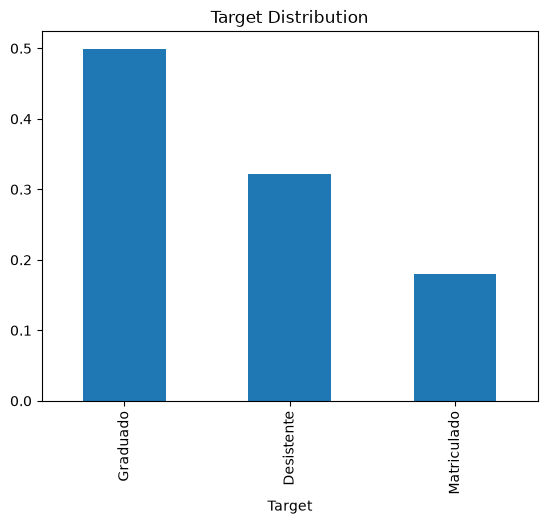

In [4]:
#Verificando a distribuição da variável alvo
df_students['Target'].value_counts(normalize=True).plot(kind='bar', title='Target Distribution')

In [5]:
#Verificando possíveis valores nulos existentes no dataset
print(df_students.isna().sum())

EstadoCivil                                   0
Curso                                         0
QualificacaoAnterior                          0
QualificacaoAnteriorGrau                      0
Nacionalidade                                 0
NotaAdmissao                                  0
NecessidadesEspeciais                         0
Devedor                                       0
MensalidadesEmDia                             0
Genero                                        0
Bolsista                                      0
International                                 0
UnidadesCurriculares1SemestreCreditado        0
UnidadesCurriculares1SemestreInscrito         0
UnidadesCurriculares1SemestreAvaliacoes       0
UnidadesCurriculares1SemestreAprovado         0
UnidadesCurriculares1SemestreGrau             0
UnidadesCurriculares1SemestreSemAvaliacoes    0
UnidadesCurriculares2SemestreCreditado        0
UnidadesCurriculares2SemestreInscrito         0
UnidadesCurriculares2SemestreAvaliacoes 

In [6]:
#Verificando os tipos de dados das colunas do dataset
df_students.dtypes

EstadoCivil                                       str
Curso                                             str
QualificacaoAnterior                              str
QualificacaoAnteriorGrau                      float64
Nacionalidade                                     str
NotaAdmissao                                  float64
NecessidadesEspeciais                           int64
Devedor                                         int64
MensalidadesEmDia                               int64
Genero                                            str
Bolsista                                        int64
International                                   int64
UnidadesCurriculares1SemestreCreditado          int64
UnidadesCurriculares1SemestreInscrito           int64
UnidadesCurriculares1SemestreAvaliacoes         int64
UnidadesCurriculares1SemestreAprovado           int64
UnidadesCurriculares1SemestreGrau             float64
UnidadesCurriculares1SemestreSemAvaliacoes      int64
UnidadesCurriculares2Semestr

In [7]:
df_students.select_dtypes(include='str').nunique()

EstadoCivil              6
Curso                   17
QualificacaoAnterior    16
Nacionalidade           21
Genero                   2
Target                   3
dtype: int64

# DataFrame ok, vamos separa-lo e iniciar o feature engineer

In [8]:
# Separamos os alunos matriculados que ainda não possuem um desfecho dos que já possuem um desfecho (graduado ou desistente)

df_enrolled = df_students[df_students['Target'] == 'Matriculado']
df_outcomes = df_students[df_students['Target'] != 'Matriculado']
df_enrolled.shape, df_outcomes.shape

((794, 28), (3630, 28))

In [9]:
target_map = {'Desistente': 1, 'Graduado': 0}
df_outcomes['Target'] = df_outcomes['Target'].map(target_map)

In [10]:
df_outcomes['Target'].value_counts(normalize=True)

Target
0    0.60854
1    0.39146
Name: proportion, dtype: float64

In [11]:
# Vamos separar as colunas com dados categóricos das colunas com dados numéricos para facilitar os transformers.
# imputer+scaler pras numéricas, imputer+encoder pras categóricas.

categorical_cols = [
    'EstadoCivil',
    'Curso',
    'QualificacaoAnterior',
    'Nacionalidade',
    'Genero'
]

numeric_cols = [
    'QualificacaoAnteriorGrau',
    'NotaAdmissao',
    'NecessidadesEspeciais',
    'Devedor',
    'MensalidadesEmDia',
    'Bolsista',
    'International',
    'UnidadesCurriculares1SemestreCreditado',
    'UnidadesCurriculares1SemestreInscrito',
    'UnidadesCurriculares1SemestreAvaliacoes',
    'UnidadesCurriculares1SemestreAprovado',
    'UnidadesCurriculares1SemestreGrau',
    'UnidadesCurriculares1SemestreSemAvaliacoes',
    'UnidadesCurriculares2SemestreCreditado',
    'UnidadesCurriculares2SemestreInscrito',
    'UnidadesCurriculares2SemestreAvaliacoes',
    'UnidadesCurriculares2SemestreAprovado',
    'UnidadesCurriculares2SemestreGrau',
    'UnidadesCurriculares2SemestreSemAvaliacoes',
    'TaxaDesemprego',
    'TaxaInflacao',
    'PIB'
]

In [12]:
# Tem gente que nem chegou a se inscrever em nenhuma matéria no ano — aí a taxa de
# aprovação vira 0/0, que é indefinido. Pra não confundir esse pessoal com quem
# reprovou em tudo, criamos uma flag separada pra marcar eles e então preenchemos a taxa com 0.
# Também aproveitamos pra ver se o aluno melhorou ou piorou do 1º pro 2º semestre.


def add_academic_performance_features(df, numeric_cols):
    df = df.copy()

    df['no_courses_full_year'] = (
        (df['UnidadesCurriculares1SemestreInscrito'] == 0) &
        (df['UnidadesCurriculares2SemestreInscrito'] == 0)
    ).astype(int)

    df['approval_rate_sem1'] = (
        df['UnidadesCurriculares1SemestreAprovado'] / df['UnidadesCurriculares1SemestreInscrito']
    ).fillna(0)

    df['approval_rate_sem2'] = (
        df['UnidadesCurriculares2SemestreAprovado'] / df['UnidadesCurriculares2SemestreInscrito']
    ).fillna(0)

    df['grade_delta'] = df['UnidadesCurriculares2SemestreGrau'] - df['UnidadesCurriculares1SemestreGrau']
    df['approval_rate_delta'] = df['approval_rate_sem2'] - df['approval_rate_sem1']

    new_cols = [
        'no_courses_full_year',
        'approval_rate_sem1',
        'approval_rate_sem2',
        'grade_delta',
        'approval_rate_delta',
    ]
    numeric_cols.extend([col for col in new_cols if col not in numeric_cols])

    return df

In [13]:
def build_pipeline(numeric_cols, categorical_cols):
    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    return ColumnTransformer(transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ])

In [14]:
df_featured = add_academic_performance_features(df_outcomes, numeric_cols)
df_featured[['no_courses_full_year', 'approval_rate_sem1', 'approval_rate_sem2', 'grade_delta', 'approval_rate_delta']].describe()

,no_courses_full_year,approval_rate_sem1,approval_rate_sem2,grade_delta,approval_rate_delta
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,0.041873,0.699966,0.662755,-0.498705,-0.037211
std,0.200327,0.378162,0.400434,2.954093,0.176821
min,0.000000,0.000000,0.000000,-16.142857,-1.000000
25%,0.000000,0.500000,0.333333,-0.533333,0.000000
50%,0.000000,0.857143,0.857143,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.400000,0.000000
max,1.000000,1.000000,1.000000,14.500000,1.000000


# Feature Engineer completa, vamos ao split dos dados.

In [17]:
X = df_featured.drop(columns=['Target'])
y = df_featured['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2904, 32), (726, 32), (2904,), (726,))